<a href="https://colab.research.google.com/github/zinababdalkhalek4/Digital-Image-Processing-DIP-/blob/main/plant_leaf_segmentation_and_classification_Phase_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage import color
from scipy import ndimage
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os


In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')
train_path = "/content/drive/MyDrive/output_DIP"

Mounted at /content/drive


In [ ]:
import os
output_path = "/content/drive/MyDrive/output_DIP/preprocessed_dataset"
print("Train path exists:", os.path.exists(output_path))
print("Train content:", os.listdir(train_path))

Train path exists: True
Train content: ['Pongamia_Pinnata_(P7)', 'Mango_(P0)', 'Lemon_(P10)', 'Pomegranate_(P9)', 'Jamun_(P5)', 'Jatropha_(P6)', 'Basil_(P8)', 'Chinar_(P11)', 'Arjun_(P1)', 'Alstonia_Scholaris_(P2)', 'preprocessed_dataset', 'final_segmented_images', 'features.csv']


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
from scipy.fft import fft

seg_folder = "/content/drive/MyDrive/output_DIP/final_segmented_images"
classes = [cls for cls in os.listdir(seg_folder) if os.path.isdir(os.path.join(seg_folder, cls))]

all_features = []

def fourier_descriptors(contour, n_descriptors=10):
    # Reshape contour to (N, 2) and convert to complex
    contour_array = contour[:, 0, :]  # Shape: (N, 2)
    complex_contour = contour_array[:, 0] + 1j * contour_array[:, 1]

    # Compute FFT
    fd = fft(complex_contour)
    fd = np.abs(fd[1:n_descriptors+1])  # Skip DC component

    # Normalize by the first descriptor for scale invariance
    if fd[0] != 0:
        fd /= fd[0]

    return fd

def region_features(contour):
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    circularity = (4 * np.pi * area) / (perimeter**2) if perimeter != 0 else 0

    hull = cv2.convexHull(contour)
    hull_perimeter = cv2.arcLength(hull, True)
    hull_area = cv2.contourArea(hull)

    convexity = hull_perimeter / perimeter if perimeter != 0 else 0
    compactness = area / (perimeter**2) if perimeter != 0 else 0

    # Moments
    M = cv2.moments(contour)
    hu_moments = cv2.HuMoments(M).flatten()

    features = [area, perimeter, circularity, convexity, compactness]
    features.extend(hu_moments)

    return features

for cls in classes:
    class_path = os.path.join(seg_folder, cls)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Processing class: {cls} - {len(images)} images")

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print(f"  Skipping {img_name}: Could not read image")
            continue

        # Ensure binary
        _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

        # Find contours
        contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

        for cnt in contours:
            if cv2.contourArea(cnt) < 10:
                continue

            b_features = fourier_descriptors(cnt, n_descriptors=10)
            r_features = region_features(cnt)

            all_features.append([cls, img_name] + b_features.tolist() + r_features)

columns = ['Class', 'Image']
columns += [f'FD{i+1}' for i in range(10)]
columns += ['Area', 'Perimeter', 'Circularity', 'Convexity', 'Compactness']
columns += [f'HU{i+1}' for i in range(7)]

df_features = pd.DataFrame(all_features, columns=columns)
df_features.to_csv("/content/drive/MyDrive/output_DIP/features.csv", index=False)
print("Features saved! Total features extracted:", len(all_features))

Processing class: Pongamia_Pinnata_(P7) - 319 images
Processing class: Mango_(P0) - 170 images
Processing class: Lemon_(P10) - 159 images
Processing class: Pomegranate_(P9) - 286 images
Processing class: Jamun_(P5) - 267 images
Processing class: Jatropha_(P6) - 131 images
Processing class: Basil_(P8) - 148 images
Processing class: Chinar_(P11) - 103 images
Processing class: Arjun_(P1) - 214 images
Processing class: Alstonia_Scholaris_(P2) - 174 images


PermissionError: [Errno 1] Operation not permitted: '/content/drive/MyDrive/output_DIP/features.csv'

In [ ]:
df_features.head()

,Class,Image,FD1,FD2,FD3,FD4,FD5,FD6,FD7,FD8,...,Circularity,Convexity,Compactness,HU1,HU2,HU3,HU4,HU5,HU6,HU7
0,Pongamia_Pinnata_(P7),0007_0022.JPG,1.0,1.628724,1.068408,0.196802,0.131878,0.158232,0.271471,0.117822,...,0.259835,0.572917,0.020677,0.200930,0.000308,0.000016,6.365973e-05,-1.511803e-09,-1.054359e-06,-1.362556e-09
1,Pongamia_Pinnata_(P7),0007_0019.JPG,1.0,0.617734,0.480245,0.331949,0.129006,0.079681,0.130257,0.014782,...,0.688202,0.916529,0.054765,0.166817,0.001089,0.000159,1.268857e-05,5.648085e-10,4.036674e-07,-7.170419e-11
2,Pongamia_Pinnata_(P7),0007_0037.JPG,1.0,0.076621,0.230597,0.095369,0.106578,0.056889,0.059160,0.049674,...,0.801993,0.943520,0.063821,0.167435,0.002413,0.000003,6.992350e-08,1.754508e-14,1.719632e-09,2.637724e-14
3,Pongamia_Pinnata_(P7),0007_0060.JPG,1.0,0.603506,0.232978,0.177037,0.057079,0.272558,0.410104,0.165495,...,0.195914,0.525711,0.015590,0.222460,0.004892,0.001177,1.841553e-04,2.066582e-09,-1.032012e-05,-8.570166e-08
4,Pongamia_Pinnata_(P7),0007_0021.JPG,1.0,0.319695,0.035360,0.086077,0.050808,0.021114,0.049828,0.019978,...,0.807875,0.943198,0.064289,0.171245,0.003448,0.000156,6.080911e-06,1.620866e-10,3.031553e-07,9.345694e-11


In [ ]:
classes

['Pongamia_Pinnata_(P7)',
 'Mango_(P0)',
 'Lemon_(P10)',
 'Pomegranate_(P9)',
 'Jamun_(P5)',
 'Jatropha_(P6)',
 'Basil_(P8)',
 'Chinar_(P11)',
 'Arjun_(P1)',
 'Alstonia_Scholaris_(P2)']

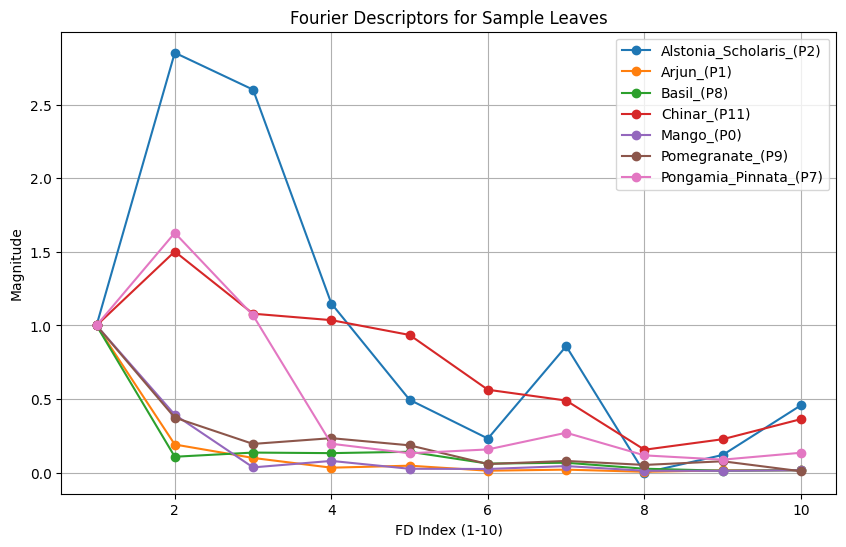

In [ ]:
import matplotlib.pyplot as plt
sample_classes = ['Alstonia_Scholaris_(P2)', 'Arjun_(P1)', 'Basil_(P8)', 'Chinar_(P11)', 'Mango_(P0)', 'Pomegranate_(P9)', 'Pongamia_Pinnata_(P7)']

plt.figure(figsize=(10,6))
for cls in sample_classes:

    sample_fd = df_features[df_features['Class']==cls].iloc[0, 2:12].values  # FD1-FD10
    plt.plot(range(1,11), sample_fd, marker='o', label=cls)

plt.xlabel("FD Index (1-10)")
plt.ylabel("Magnitude")
plt.title("Fourier Descriptors for Sample Leaves")
plt.legend()
plt.grid(True)
plt.show()

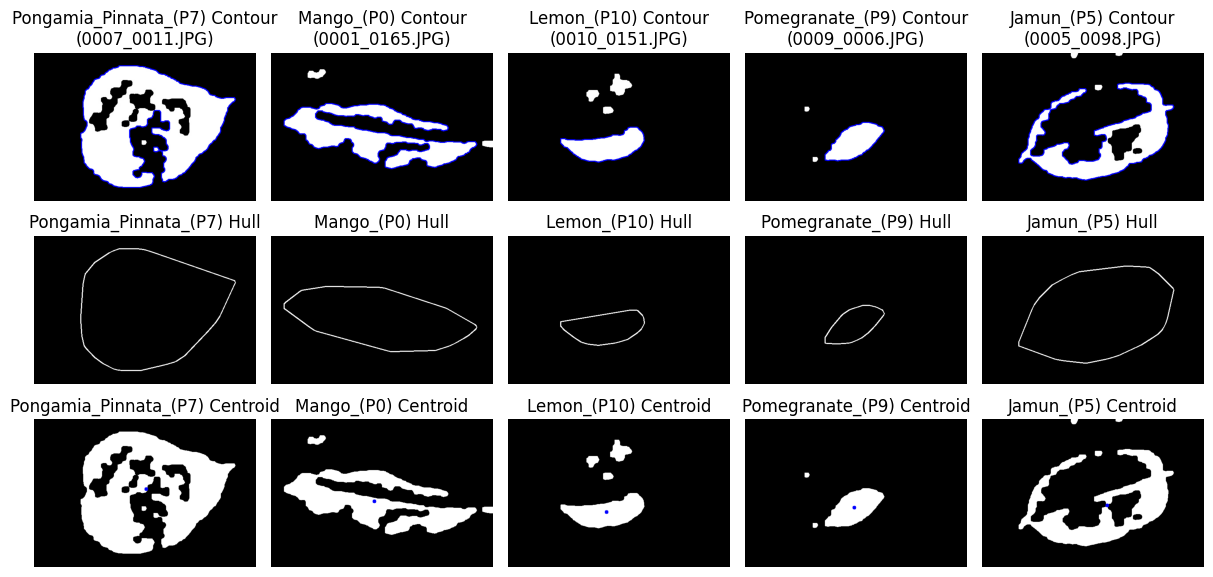

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

seg_folder = "/content/drive/MyDrive/output_DIP/final_segmented_images"


classes = [cls for cls in os.listdir(seg_folder) if os.path.isdir(os.path.join(seg_folder, cls))]

classes = classes[:5]

plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    class_path = os.path.join(seg_folder, cls)

    # Get list of image files in the class folder
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if not images:
        print(f"No images found in class '{cls}'. Skipping.")
        continue

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    # Load image as grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Failed to load image '{img_path}'. Skipping.")
        continue

    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Find contours
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        print(f"No contours found in '{img_name}' for class '{cls}'. Skipping.")
        continue
    largest_contour = max(contours, key=cv2.contourArea)

    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    cv2.drawContours(img_color, [largest_contour], -1, (255, 0, 0), 2)

    # Plot contour
    plt.subplot(3, len(classes), i + 1)
    plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
    plt.title(f"{cls} Contour\n({img_name})")
    plt.axis('off')

    hull = cv2.convexHull(largest_contour)
    hull_img = np.zeros_like(binary)
    cv2.drawContours(hull_img, [hull], -1, 255, 2)

    plt.subplot(3, len(classes), i + 1 + len(classes))
    plt.imshow(hull_img, cmap='gray')
    plt.title(f"{cls} Hull")
    plt.axis('off')

    M = cv2.moments(largest_contour)
    cx, cy = 0, 0
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])

    center_img = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    cv2.circle(center_img, (cx, cy), 5, (255, 0, 0), -1)

    plt.subplot(3, len(classes), i + 1 + 2 * len(classes))
    plt.imshow(cv2.cvtColor(center_img, cv2.COLOR_BGR2RGB))
    plt.title(f"{cls} Centroid")
    plt.axis('off')

# Adjust layout and display
plt.tight_layout()
plt.show()
plt.close()

In [ ]:

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("/content/drive/MyDrive/output_DIP/features.csv")

X = df.drop(columns=['Class', 'Image'])
y = df['Class']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{i} -> {cls}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


Class mapping:
0 -> Alstonia_Scholaris_(P2)
1 -> Arjun_(P1)
2 -> Basil_(P8)
3 -> Chinar_(P11)
4 -> Jamun_(P5)
5 -> Jatropha_(P6)
6 -> Lemon_(P10)
7 -> Mango_(P0)
8 -> Pomegranate_(P9)
9 -> Pongamia_Pinnata_(P7)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=4000,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_scaled, y_train)



RandomForestClassifier(class_weight='balanced', n_estimators=4000,
                       random_state=42)

In [ ]:

y_pred = rf.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))



Test Accuracy: 0.3278217109992811

Classification Report:

                         precision    recall  f1-score   support

Alstonia_Scholaris_(P2)       0.26      0.18      0.21       207
             Arjun_(P1)       0.36      0.23      0.28       102
             Basil_(P8)       0.25      0.18      0.21       118
           Chinar_(P11)       0.42      0.24      0.31        58
             Jamun_(P5)       0.38      0.33      0.35       116
          Jatropha_(P6)       0.47      0.39      0.43        70
            Lemon_(P10)       0.26      0.37      0.30       125
             Mango_(P0)       0.29      0.53      0.38       294
       Pomegranate_(P9)       0.48      0.42      0.45       118
  Pongamia_Pinnata_(P7)       0.48      0.23      0.32       183

               accuracy                           0.33      1391
              macro avg       0.37      0.31      0.32      1391
           weighted avg       0.35      0.33      0.32      1391



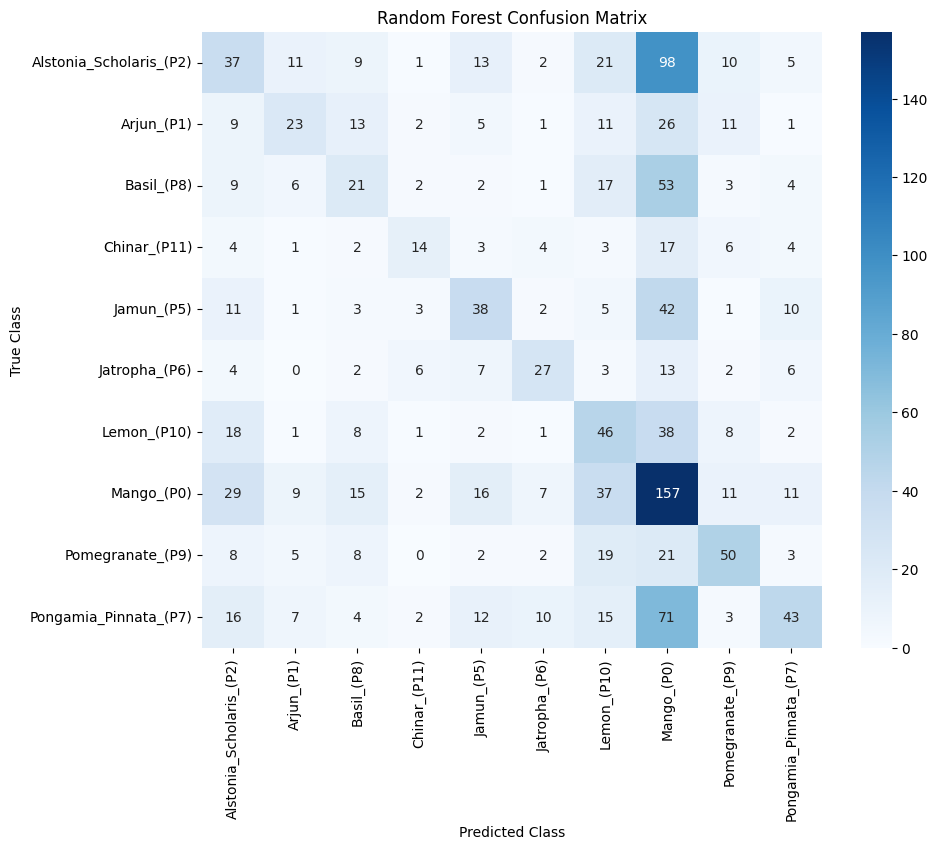

In [ ]:

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn import svm

# Parameter grid
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': [0.001, 0.01, 0.1, 1, 'scale']}
clf_grid = GridSearchCV(svm.SVC(), param_grid, cv=5, verbose=1)
clf_grid.fit(X_train_scaled, y_train)
print("Best Parameters:", clf_grid.best_params_)
print("Best Estimator:", clf_grid.best_estimator_)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'C': 100, 'gamma': 'scale'}
Best Estimator: SVC(C=100)
